In [2]:
"""
1. 导入库
2. 导入数据
3. 数据概览
4. 数据清洗
5. 新数据特征构造
6. 问题分析及可视化
"""

'\n1. 导入库\n2. 导入数据\n3. 数据概览\n4. 数据清洗\n5. 新数据特征构造\n6. 问题分析及可视化\n'

In [56]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STHeiti']

In [4]:
df = pd.read_csv('../data/house_sales.csv')

In [5]:
print('总记录数:', len(df))
print('总字段数:', len(df.columns))
print(df.info())
df.head()

总记录数: 106118
总字段数: 12
<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB
None


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


In [6]:
"""
df.info() 运行结果
<class 'pandas.DataFrame'>
Index: 26135 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   city      26135 non-null  str
 1   address   26135 non-null  str
 2   area      26135 non-null  float64
 3   floor     26135 non-null  str
 4   name      26135 non-null  str
 5   price     26135 non-null  float64
 6   province  26135 non-null  str
 7   rooms     26135 non-null  str
 8   toward    26135 non-null  category
 9   unit      26135 non-null  float64
 10  year      26135 non-null  int64
dtypes: category(1), float64(3), int64(1), str(6)
memory usage: 2.2 MB
"""

"\ndf.info() 运行结果\n<class 'pandas.DataFrame'>\nIndex: 26135 entries, 0 to 106088\nData columns (total 11 columns):\n #   Column    Non-Null Count  Dtype\n---  ------    --------------  -----\n 0   city      26135 non-null  str\n 1   address   26135 non-null  str\n 2   area      26135 non-null  float64\n 3   floor     26135 non-null  str\n 4   name      26135 non-null  str\n 5   price     26135 non-null  float64\n 6   province  26135 non-null  str\n 7   rooms     26135 non-null  str\n 8   toward    26135 non-null  category\n 9   unit      26135 non-null  float64\n 10  year      26135 non-null  int64\ndtypes: category(1), float64(3), int64(1), str(6)\nmemory usage: 2.2 MB\n"

In [7]:
# 数据清洗
df.drop(columns='origin_url', inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("残缺数据", df.isna().sum())
print("重复数据",df.duplicated().sum())
print("总条目",len(df))

残缺数据 city        0
address     0
area        0
floor       0
name        0
price       0
province    0
rooms       0
toward      0
unit        0
year        0
dtype: int64
重复数据 0
总条目 28104


In [8]:
# 数据类型转化
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50㎡,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120㎡,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建


In [9]:
df['area'] = df['area'].str.replace('㎡','').astype(float)

In [10]:
df['price'] = df['price'].str.replace('万','').astype(float)

In [11]:
df['toward'].value_counts()
df['toward'] = df['toward'].astype('category')

In [12]:
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)

In [13]:
df['year'] = df['year'].str.replace('年建','').astype(int)

In [14]:
# 异常值处理
print(len(df))
print(len(df[(df['area'] < 600) & (df['area'] > 20)]))
df = df[(df['area'] < 600) & (df['area'] > 20)]

28104
28079


In [15]:
# 售价异常处理 IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_price = Q1 - 1.5 * IQR
high_price = Q3 + 1.5 * IQR
print(Q1, Q3, IQR, low_price, high_price)
print(len(df))
df = df[ (df['price'] > low_price) & (df['price'] < high_price) ]
print(len(df))

74.0 167.0 93.0 -65.5 306.5
28079
26135


In [16]:
# 5. 新数据特征构造
# 地区 district
# 楼层的类型 floor_type
# 是否是直辖市 zxs
# 我是的数量 bedrooms
# 客厅的数量 livingrooms
# 楼龄 building_age
# 价格分箱 price_labels

In [17]:
df['district'] = df['address'].str.split('-').str[0]

In [18]:
df.sample(5)    # 随机看一看数据，寻找数据特征

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district
6438,杭州,彭埠-明月桥路和鸿泰路交汇处(地铁1、4号线彭埠站,42.0,中层（共12层）,三花国际公寓,128.0,浙江,2室2厅,南北向,30476.0,2018,彭埠
66472,惠州,西区-石化大道西333号,98.4,中层（共32层）,锦地繁花,99.0,广东,3室2厅,南向,10061.0,2019,西区
90318,怀远,太平街-朝阳路与兴中路交叉口十一中对面(光彩玉器城南,171.0,高层（共12层）,南山郦都,158.0,安徽,4室3厅,南北向,9240.0,2013,太平街
61424,昌黎,北戴河其他-新区大蒲河镇东沙河左大桥西500米,102.0,中层（共11层）,北戴河孔雀城,85.0,河北,3室2厅,南北向,8333.0,2018,北戴河其他
8028,冀州,路北-榕华大街与大庆路交叉口南行100米路东,89.0,高层（共20层）,康城世纪,69.8,河北,2室2厅,南向,7843.0,2011,路北


In [19]:
df['floor_type'] = df['floor'].str.split('（').str[0]

In [20]:
"""
函数处理模板
"""
def fun(s):
    return s
df['floor'].apply(fun)

0         中层（共18层）
2         中层（共18层）
4         中层（共22层）
6         高层（共30层）
8         中层（共27层）
            ...   
106080     中层（共6层）
106082    中层（共26层）
106084    高层（共25层）
106086    低层（共18层）
106088    低层（共18层）
Name: floor, Length: 26135, dtype: str

In [21]:
import re
def floor_number(s):
    if pd.isna(s):
        return -1
    else:
        match = re.search(r'\d+', s)
        if match:
            number = int(match.group(0))
            return number
        else:
            return -1
df['max_floor'] = df['floor'].apply(floor_number)

In [22]:
df['floor_type'] = df['floor_type'].astype('category')
df.info()

<class 'pandas.DataFrame'>
Index: 26135 entries, 0 to 106088
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        26135 non-null  str     
 1   address     26135 non-null  str     
 2   area        26135 non-null  float64 
 3   floor       26135 non-null  str     
 4   name        26135 non-null  str     
 5   price       26135 non-null  float64 
 6   province    26135 non-null  str     
 7   rooms       26135 non-null  str     
 8   toward      26135 non-null  category
 9   unit        26135 non-null  float64 
 10  year        26135 non-null  int64   
 11  district    26135 non-null  object  
 12  floor_type  26135 non-null  category
 13  max_floor   26135 non-null  int64   
dtypes: category(2), float64(3), int64(2), object(1), str(6)
memory usage: 2.6+ MB


In [23]:
def is_zxs(s):
    if s in ['北京','天津','上海','重庆']:
        return True
    else:
        return False
df['is_zxs'] = df['city'].apply(is_zxs) # apply 里面还可以用匿名函数 lambda
df.info()

<class 'pandas.DataFrame'>
Index: 26135 entries, 0 to 106088
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        26135 non-null  str     
 1   address     26135 non-null  str     
 2   area        26135 non-null  float64 
 3   floor       26135 non-null  str     
 4   name        26135 non-null  str     
 5   price       26135 non-null  float64 
 6   province    26135 non-null  str     
 7   rooms       26135 non-null  str     
 8   toward      26135 non-null  category
 9   unit        26135 non-null  float64 
 10  year        26135 non-null  int64   
 11  district    26135 non-null  object  
 12  floor_type  26135 non-null  category
 13  max_floor   26135 non-null  int64   
 14  is_zxs      26135 non-null  bool    
dtypes: bool(1), category(2), float64(3), int64(2), object(1), str(6)
memory usage: 2.7+ MB


In [24]:
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)

In [25]:
# df['livingrooms'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)

In [31]:
import datetime

now_year = datetime.datetime.now().year
df['building_age'] = now_year - df['year'].astype(int)

In [34]:
df['price_labels'] = pd.cut(df['price'], bins=4, labels=['low','median','high','luxuries']).astype('category')

In [36]:
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,max_floor,is_zxs,bedrooms,livingrooms,building_age,price_labels
33010,临沂,沂河路-滨河西路与沂河路交汇向南两百米路西,120.0,中层（共11层）,白鹭金岸,135.0,山东,3室2厅,南向,11250.0,2016,沂河路,中层,11,False,3,2,10,median
11056,太仓,沙溪-太仓市姚泾路6号(沙溪新政府大楼斜对面),93.0,高层（共1层）,印溪佳园,139.0,江苏,3室1厅,南向,14946.0,2015,沙溪,高层,1,False,3,1,11,median
96726,邵阳,蔡锷路-西湖北路,120.0,高层（共29层）,恒大华府,72.0,湖南,3室2厅,南北向,6000.0,2019,蔡锷路,高层,29,False,3,2,7,low
33432,如皋,如皋市区-如皋-如皋市区-龙游湖壹号,109.0,中层（共12层）,龙游湖壹号,95.0,江苏,3室2厅,南北向,8716.0,2015,如皋市区,中层,12,False,3,2,11,median
18750,宾阳,新阳路-明秀西路170号(中兴桥北),89.0,中层（共32层）,龙光水悦龙湾,98.0,广西,3室2厅,南向,11011.0,2018,新阳路,中层,32,False,3,2,8,median


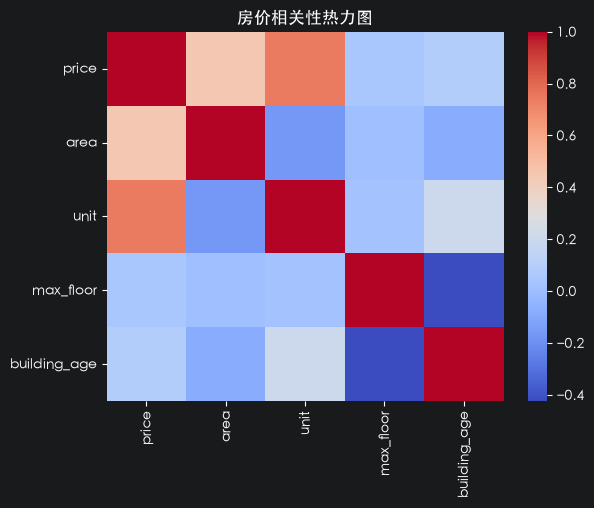

In [63]:
# A1 房价相关性报告
# 指标方法：皮尔逊相关系数
a = df[['price', 'area', 'unit', 'max_floor','building_age']].corr()
a['price'].sort_values(ascending=False).plot(kind='bar')
sns.heatmap(a, cmap='coolwarm')
plt.title('房价相关性热力图')
plt.show()

In [47]:
df.describe().round(2)

,area,price,unit,year,max_floor,bedrooms,livingrooms,building_age
count,26135.00,26135.00,26135.00,26135.00,26135.00,26135.00,26135.00,26135.00
mean,103.76,117.21,11610.13,2013.07,20.35,2.71,1.85,12.93
std,34.00,60.97,5824.25,6.02,10.48,0.80,0.41,6.02
min,21.00,9.00,1000.00,1976.00,1.00,0.00,0.00,3.00
25%,85.00,72.00,7587.00,2011.00,11.00,2.00,2.00,9.00
50%,100.00,103.00,10312.00,2015.00,20.00,3.00,2.00,11.00
75%,123.00,150.00,14184.00,2017.00,30.00,3.00,2.00,15.00
max,470.00,306.00,85288.00,2023.00,90.00,9.00,12.00,50.00


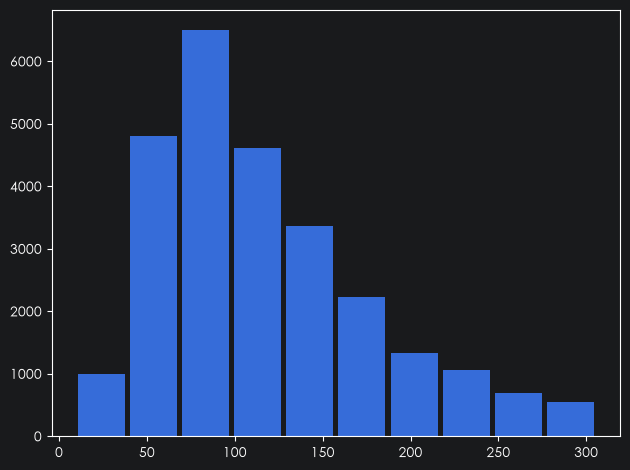

In [55]:
# A2 全国房价直方图
plt.subplot(111)
plt.hist(df['price'], bins=10, rwidth=0.9)
plt.tight_layout()
plt.show()

<Axes: xlabel='price', ylabel='Count'>

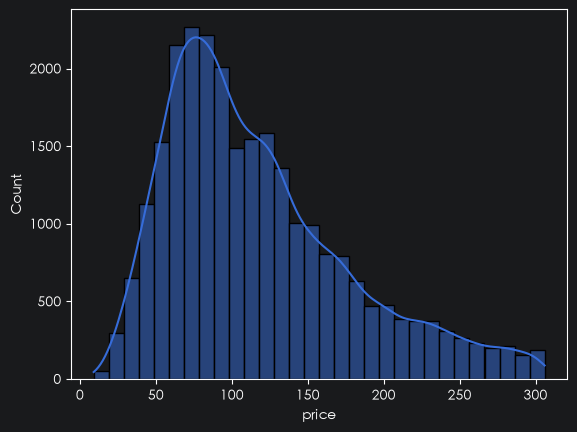

In [61]:
sns.histplot(data=df, x='price', bins=30, kde=True)

In [65]:
# A6 朝向溢价
df.groupby(['toward']).agg({
    'price': ['mean','median'],
    'unit': ['mean','median'],
}).round(2)

price             unit         
          mean median      mean   median
toward                                  
东北向     114.56  100.0  12350.30  12198.0
东南向     115.54  105.0  11795.63  10864.0
东向      110.16   95.0  12404.77  11421.0
东西向      98.94   82.0  10854.01   9000.0
北向       92.53   75.5  12351.86  11698.0
南北向     119.47  104.5  11166.99  10000.0
南向      114.56  103.0  12114.22  10759.0
西北向     119.11  105.0  13434.15  12290.0
西南向     139.71  138.4  14916.50  13333.0
西向      102.66   86.0  14162.16  12528.0

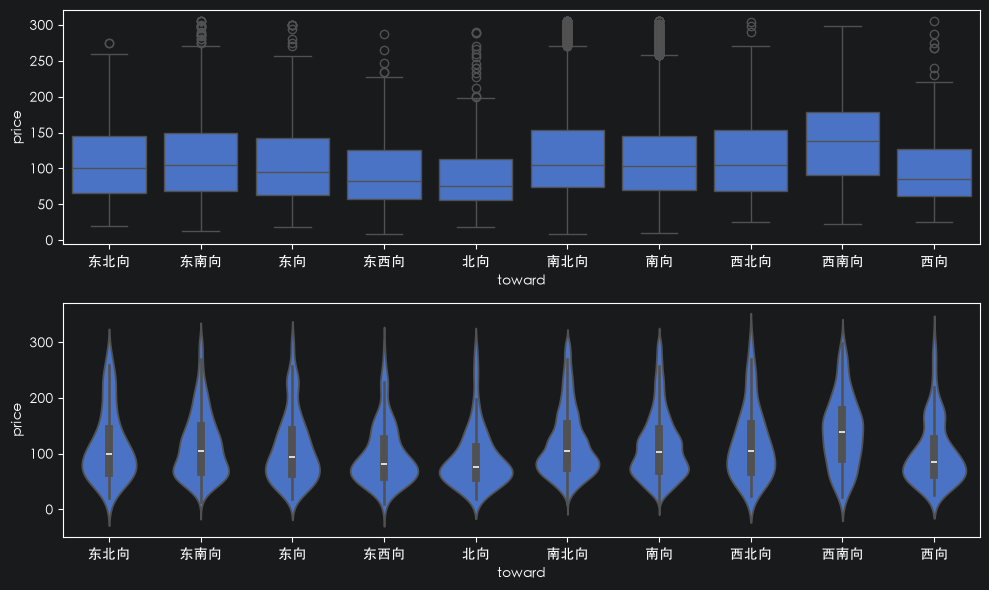

In [78]:
plt.figure(figsize=(10,6))
plt.subplot(211)
sns.boxplot(data=df, x='toward', y='price')
plt.subplot(212)
sns.violinplot(data=df, x='toward', y='price')
plt.tight_layout()
plt.show()